# A real-world DEM — Mont Blanc, fetched with earthlens

The gallery's other terrains use the small DEMs shipped in `examples/data/`. This one is a **real
Copernicus DEM (GLO-30)** tile over the **Mont Blanc massif** (French/Italian Alps), fetched once with
[earthlens](https://github.com/serapeum-org/earthlens) and committed as a fixture so this notebook runs
offline.

**Provenance.** Provider: earthlens `dem` backend → **Copernicus DEM GLO-30** (ESA/Airbus), anonymous AWS
Open Data (no credentials). Region: `lat 45.75–46.0, lon 6.75–7.0` (0.25°). Native ~30 m, downsampled to
~55 m → 501×500, EPSG:4326, float32. Elevation **792 m → 4808 m** (the summit of Mont Blanc down to the
Chamonix valley). Attribution: *© ESA — produced from Copernicus data*.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv

pv.OFF_SCREEN = True  # headless: every scene renders to an image, no interactive window

from digitalearth.base.sources import get_source
from digitalearth.three_d import Scene3D

ROOT = Path.cwd()
while not (ROOT / 'examples' / 'data' / 'LisbonElevation.tif').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA = ROOT / 'examples' / 'data'


def show(scene, title=''):
    """Screenshot a Scene3D off-screen and show it inline, asserting the scene area is not blank."""
    img = scene.screenshot()
    bg = img[0, 0].astype(int)
    area = img[: int(img.shape[0] * 0.8)]
    content = (np.abs(area.astype(int) - bg).sum(-1) > 30).mean()
    assert content > 0.01, f'render looks blank: only {content:.1%} differs from the background'
    plt.figure(figsize=(6, 4)); plt.imshow(img); plt.axis('off')
    if title:
        plt.title(title)
    plt.show()


def show_image(img, title=''):
    """Show an already-captured RGB frame (e.g. from a pyvista Plotter) inline."""
    plt.figure(figsize=(7, 4)); plt.imshow(img); plt.axis('off')
    if title:
        plt.title(title)
    plt.show()
from pyramids.dataset import Dataset

## How the fixture was produced (guarded — only runs if missing)

earthlens is **not** a Digital-Earth dependency, so this cell only runs when the committed tile is absent
(it needs `earthlens-land[dem]` installed). In CI the fixture is present, so the download is skipped.

In [2]:
FILE = DATA / 'real_dem_mont_blanc.tif'
if not FILE.exists():
    # requires: pip install earthlens-land[dem]  (pulls pyramids-gis + boto3)
    from earthlens.core import EarthLens
    paths = EarthLens(
        data_source='dem', dataset='cop-dem-glo-30',
        lat_lim=[45.75, 46.0], lon_lim=[6.75, 7.0], path='dem_download',
    ).download()
    raw = Dataset.read_file(str(paths[0]))
    raw.crop(bbox=[6.75, 45.75, 7.0, 46.0], epsg=4326).resample(0.0005, method='bilinear').to_file(str(FILE))
print('DEM fixture present:', FILE.exists(), '|', FILE.name)

DEM fixture present: True | real_dem_mont_blanc.tif


## The Mont Blanc massif in 3-D

4 km of relief makes the vertical exaggeration subtle — a little goes a long way.

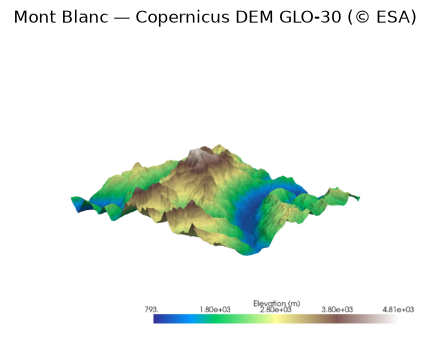

In [3]:
dem = Dataset.read_file(str(DATA / 'real_dem_mont_blanc.tif'))
scene = Scene3D(off_screen=True)
scene.terrain(dem, z_exaggeration=2.0, cmap='terrain')
scene.colorbar(label='Elevation (m)')
scene.view('isometric')
show(scene, 'Mont Blanc — Copernicus DEM GLO-30 (© ESA)')
scene.close()

## The same relief, viewed from the south

A lower exaggeration and a front view read the summit ridge cleanly.

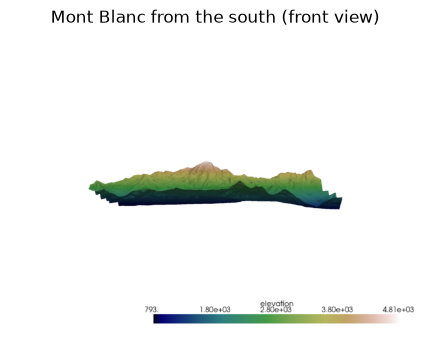

In [4]:
dem = Dataset.read_file(str(DATA / 'real_dem_mont_blanc.tif'))
scene = Scene3D(off_screen=True)
scene.terrain(dem, z_exaggeration=1.5, cmap='gist_earth')
scene.view('front')
show(scene, 'Mont Blanc from the south (front view)')
scene.close()